# Notebook 11: Learning Curves and Feature Ablation

Two analyses here:
1. Learning curves: how does model performance change as the training set size grows? Useful for asking whether more data would actually help.
2. Ablation study: how much does each feature group actually contribute?

In [1]:
import pandas as pd
import numpy as np
import json
import re
import matplotlib.pyplot as plt
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.model_selection import learning_curve, cross_val_score
from sklearn.linear_model import LogisticRegression

train_df = pd.read_csv('../data/raw/MTS-Dialog-TrainingSet.csv')
section_mapping = {
    'GENHX': 'History', 'FAM/SOCHX': 'History', 'PASTMEDICALHX': 'History',
    'PASTSURGICAL': 'History', 'OTHER_HISTORY': 'History', 'GYNHX': 'History',
    'CC': 'Chief Complaint', 'ROS': 'Exam/Review', 'EXAM': 'Exam/Review',
    'ALLERGY': 'Medications/Allergies', 'MEDICATIONS': 'Medications/Allergies',
    'IMMUNIZATIONS': 'Medications/Allergies',
    'ASSESSMENT': 'Assessment/Diagnosis', 'DIAGNOSIS': 'Assessment/Diagnosis',
    'PLAN': 'Plan/Disposition', 'DISPOSITION': 'Plan/Disposition',
    'EDCOURSE': 'Plan/Disposition', 'PROCEDURES': 'Plan/Disposition',
    'IMAGING': 'Plan/Disposition', 'LABS': 'Plan/Disposition',
}
train_df['section_group'] = train_df['section_header'].map(section_mapping)

tfidf = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1,2), min_df=2, max_df=0.95)
X_tfidf = tfidf.fit_transform(train_df['dialogue'])

def extract_dialogue_features(df):
    features = pd.DataFrame()
    features['word_count'] = df['dialogue'].str.split().str.len()
    features['turn_count'] = df['dialogue'].str.count(r'Doctor:|Patient:|\[doctor\]|\[patient\]')
    features['doctor_words'] = df['dialogue'].apply(
        lambda x: len(' '.join(re.findall(r'(?:Doctor|doctor).*?(?=Patient|patient|$)', x, re.DOTALL)).split()))
    features['patient_words'] = df['dialogue'].apply(
        lambda x: len(' '.join(re.findall(r'(?:Patient|patient).*?(?=Doctor|doctor|$)', x, re.DOTALL)).split()))
    features['avg_turn_length'] = features['word_count'] / features['turn_count'].clip(lower=1)
    return features

X_dialogue = extract_dialogue_features(train_df)
X_combined = hstack([X_tfidf, X_dialogue.values])
scaler = MaxAbsScaler()
X_scaled = scaler.fit_transform(X_combined)
y = train_df['section_group'].values

print(f"Features: {X_scaled.shape}")

Features: (1201, 505)


## Learning Curve: Section Classifier

Plotting train vs validation F1 across different training set sizes. If the gap keeps growing that's a sign of overfitting; if both converge to a plateau then we'd probably need more features rather than just more data.

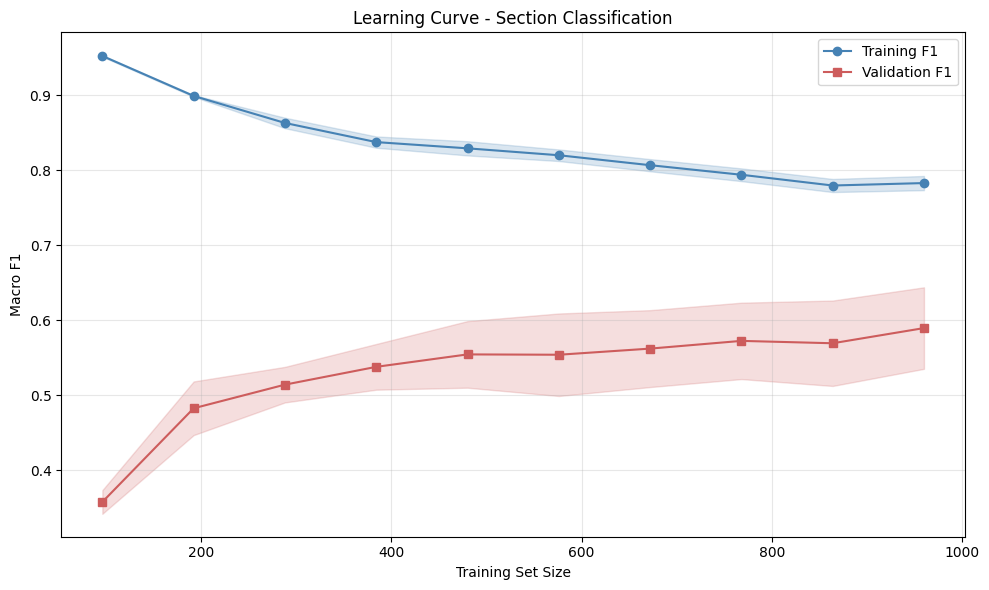

At full training size: train=0.783, val=0.590, gap=0.193


In [2]:
model = LogisticRegression(C=0.1, solver='lbfgs', class_weight='balanced', random_state=42, max_iter=2000)

train_sizes_frac = np.linspace(0.1, 1.0, 10)
train_sizes, train_scores, val_scores = learning_curve(
    model, X_scaled, y,
    train_sizes=train_sizes_frac,
    cv=5, scoring='f1_macro', n_jobs=-1, random_state=42,
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training F1')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='steelblue')
ax.plot(train_sizes, val_mean, 's-', color='indianred', label='Validation F1')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='indianred')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Macro F1')
ax.set_title('Learning Curve - Section Classification')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"At full training size: train={train_mean[-1]:.3f}, val={val_mean[-1]:.3f}, gap={train_mean[-1]-val_mean[-1]:.3f}")

## Learning Curve: Follow-Up Prediction

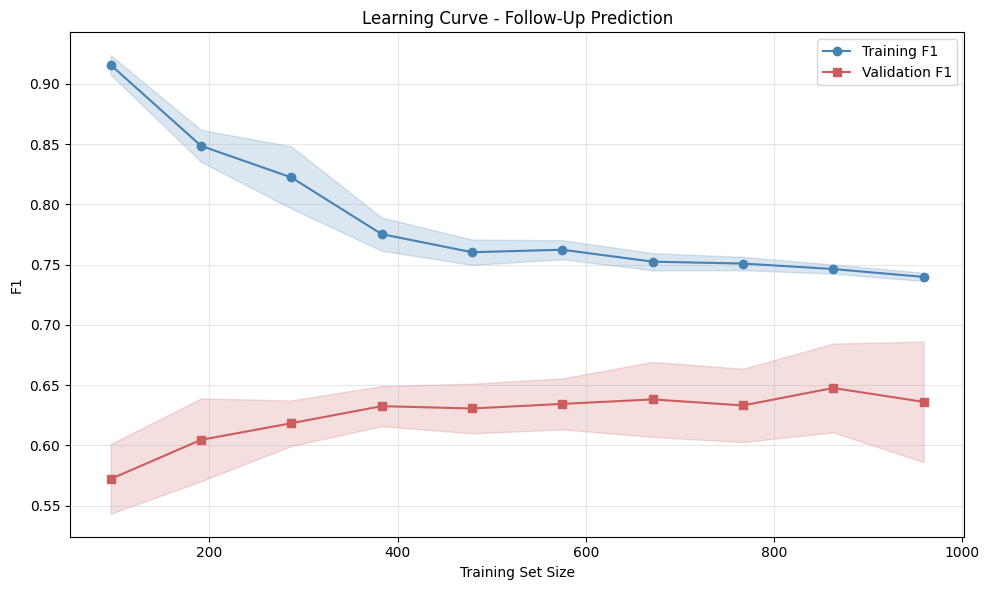

At full training size: train=0.740, val=0.636


In [3]:
with open('../data/processed/mts_entities.json') as f:
    entities = json.load(f)

fu_df = train_df.copy()
fu_df['follow_up'] = fu_df['ID'].astype(str).map(
    lambda x: entities.get(x, {}).get('follow_up_needed')
)
fu_df = fu_df.dropna(subset=['follow_up'])
fu_df['follow_up'] = fu_df['follow_up'].astype(int)

X_fu = X_scaled[fu_df.index.values]
y_fu = fu_df['follow_up'].values

train_sizes_fu, train_scores_fu, val_scores_fu = learning_curve(
    LogisticRegression(C=0.1, solver='lbfgs', class_weight='balanced', random_state=42, max_iter=2000),
    X_fu, y_fu,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='f1', n_jobs=-1, random_state=42,
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes_fu, train_scores_fu.mean(axis=1), 'o-', color='steelblue', label='Training F1')
ax.fill_between(train_sizes_fu, train_scores_fu.mean(axis=1) - train_scores_fu.std(axis=1),
                train_scores_fu.mean(axis=1) + train_scores_fu.std(axis=1), alpha=0.2, color='steelblue')
ax.plot(train_sizes_fu, val_scores_fu.mean(axis=1), 's-', color='indianred', label='Validation F1')
ax.fill_between(train_sizes_fu, val_scores_fu.mean(axis=1) - val_scores_fu.std(axis=1),
                val_scores_fu.mean(axis=1) + val_scores_fu.std(axis=1), alpha=0.2, color='indianred')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('F1')
ax.set_title('Learning Curve - Follow-Up Prediction')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"At full training size: train={train_scores_fu.mean(axis=1)[-1]:.3f}, val={val_scores_fu.mean(axis=1)[-1]:.3f}")

## Ablation Study

Does each feature group earn its place in the model? Test the section classifier with progressively more feature groups added.

In [4]:
#build entity features aligned to training data
def extract_entity_features(df, entities):
    rows = []
    for _, row in df.iterrows():
        ent = entities.get(str(row['ID']), {})
        sev = str(ent.get('severity', '')).strip().lower()
        rows.append({
            'num_symptoms': len(ent.get('symptoms', [])),
            'num_diagnoses': len(ent.get('diagnoses', [])),
            'num_medications': len(ent.get('medications', [])),
            'has_chief_complaint': int(bool(ent.get('chief_complaint', ''))),
            'severity_high': int(sev == 'high'),
            'severity_low': int(sev == 'low'),
            'has_followup': int(bool(ent.get('follow_up_needed', False))),
        })
    return pd.DataFrame(rows, index=df.index).astype(float)

X_entity = extract_entity_features(train_df, entities)

# Ablation configurations
X_tfidf_only = tfidf.transform(train_df['dialogue'])
X_tfidf_dialogue = hstack([X_tfidf_only, X_dialogue.values])
X_all = hstack([X_tfidf_only, X_dialogue.values, X_entity.values])

scaler_tfidf = MaxAbsScaler().fit(X_tfidf_only)
scaler_td = MaxAbsScaler().fit(X_tfidf_dialogue)
scaler_all = MaxAbsScaler().fit(X_all)

configs = {
    'TF-IDF only (500)': scaler_tfidf.transform(X_tfidf_only),
    'TF-IDF + dialogue (505)': scaler_td.transform(X_tfidf_dialogue),
    'TF-IDF + dialogue + entity (512)': scaler_all.transform(X_all),
}

model = LogisticRegression(C=0.1, solver='lbfgs', class_weight='balanced', random_state=42, max_iter=2000)

results = {}
print(f"{'Feature Set':40s}  {'F1':>6s}  {'Std':>6s}")
print("-" * 56)
for name, X in configs.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='f1_macro')
    results[name] = scores
    print(f"{name:40s}  {scores.mean():.3f}  {scores.std():.3f}")

Feature Set                                   F1     Std
--------------------------------------------------------
TF-IDF only (500)                         0.569  0.047
TF-IDF + dialogue (505)                   0.589  0.054
TF-IDF + dialogue + entity (512)          0.582  0.040


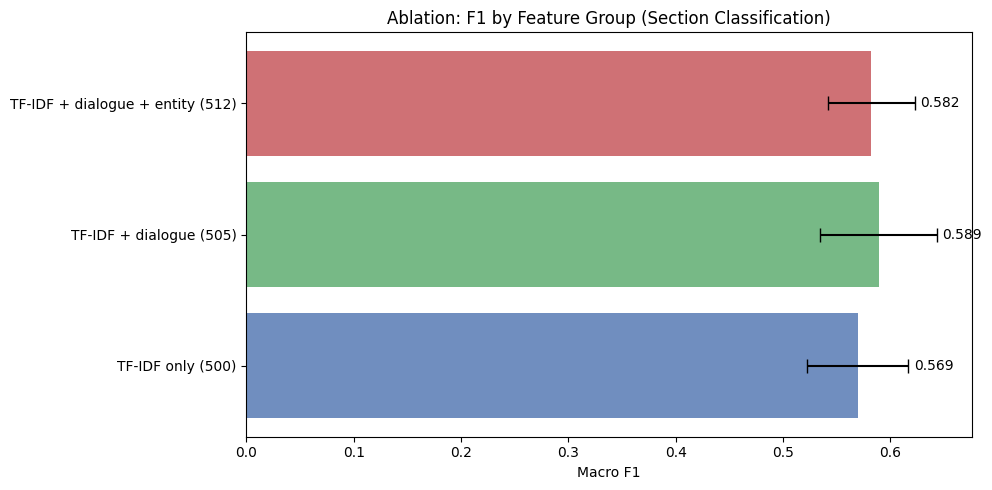


Incremental improvement:
  TF-IDF only (500) -> TF-IDF + dialogue (505): +0.020
  TF-IDF + dialogue (505) -> TF-IDF + dialogue + entity (512): -0.007


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
means = [results[n].mean() for n in names]
stds = [results[n].std() for n in names]

bars = ax.barh(names, means, xerr=stds, capsize=5, color=['#4c72b0', '#55a868', '#c44e52'], alpha=0.8)
ax.set_xlabel('Macro F1')
ax.set_title('Ablation: F1 by Feature Group (Section Classification)')

for bar, mean, std in zip(bars, means, stds):
    ax.text(mean + std + 0.005, bar.get_y() + bar.get_height()/2, f'{mean:.3f}', va='center')

plt.tight_layout()
plt.show()

print("\nIncremental improvement:")
keys = list(results.keys())
for i in range(1, len(keys)):
    delta = results[keys[i]].mean() - results[keys[i-1]].mean()
    print(f"  {keys[i-1]} -> {keys[i]}: {delta:+.3f}")